In [1]:
import os
# os.environ['CUDA_LAUNCH_BLOCKING'] = "1"
# Helpful statement for debugging, prints the thing entered as x and the output, i.e.,
# debugPrint(1+1) will output '1+1 [int] = 2'
%matplotlib widget
import inspect
import re
def debugPrint(x):
    frame = inspect.currentframe().f_back
    s = inspect.getframeinfo(frame).code_context[0]
    r = re.search(r"\((.*)\)", s).group(1)
    print("{} [{}] = {}".format(r,type(x).__name__, x))
    
    
import os, sys
import torch
import numpy as np

# Warp-based Radius Search Implementation
import warp as wp

# Initialize Warp
wp.init()

from sphWarpCore.math import *
from sphWarpCore.util import castTorchToWarp, castWarpToTorch, castTorchToWarpAsBuiltins
from sphWarpCore.radiusSearch.wp_radius_small import warp_radius_search_small
from sphWarpCore.radius import *
from warp.types import vector
from sphWarpCore.autograd import warpWrapper, WarpFunctionWrapper
from sphWarpCore.ops import *

wp.config.verify_autograd_array_access = True
wp.config.verbose = True


Warp 1.12.0 initialized:
   CUDA Toolkit 12.9, Driver 13.0
   Devices:
     "cpu"      : "x86_64"
     "cuda:0"   : "NVIDIA GeForce RTX 3090" (24 GiB, sm_86, mempool enabled)
   Kernel cache:
     /home/winchenbach/.cache/warp/1.12.0


In [2]:
@torch.jit.script
def volumeToSupport(volume : float, targetNeighbors : int, dim : int):
    """
    Calculates the support radius based on the given volume, target number of neighbors, and dimension.

    Parameters:
    volume (float): The volume of the support region.
    targetNeighbors (int): The desired number of neighbors.
    dim (int): The dimension of the space.

    Returns:
    torch.Tensor: The support radius.
    """
    if dim == 1:
        # N_h = 2 h / v -> h = N_h * v / 2
        return targetNeighbors * volume / 2
    elif dim == 2:
        # N_h = \pi h^2 / v -> h = \sqrt{N_h * v / \pi}
        return torch.sqrt(targetNeighbors * volume / np.pi)
    else:
        # N_h = 4/3 \pi h^3 / v -> h = \sqrt[3]{N_h * v / \pi * 3/4}
        return torch.pow(targetNeighbors * volume / np.pi * 3 /4, 1/3)
    
def generateNeighborTestData(nx, targetNumNeighbors, dim, periodic, device):


    minDomain = torch.tensor([-1] * dim, dtype = torch.float32, device = device)
    maxDomain = torch.tensor([ 1] * dim, dtype = torch.float32, device = device)
    periodicity = torch.tensor([periodic] * dim, device = device, dtype = torch.bool)

    extent = maxDomain - minDomain
    shortExtent = torch.min(extent, dim = 0)[0].item()
    dx = (shortExtent / nx)
    ny = int(1 // dx)
    h = volumeToSupport(dx**dim, targetNumNeighbors, dim)
    dy = dx / 1.5
    ny = int(1 // dy)

    positions = []
    for d in range(dim):
        positions.append(torch.linspace(minDomain[d] + dx / 2, maxDomain[d] - dx / 2, int((extent[d] - dx) / dx) + 1, device = device))
    grid = torch.meshgrid(*positions, indexing = 'xy')
    
    positions = torch.stack(grid, dim = -1).reshape(-1,dim).to(device)
    supports = torch.ones(positions.shape[0], device = device) * h
    
    domain = DomainDescription(minDomain, maxDomain, periodicity, dim)
    
    return positions, supports, positions.shape[0], domain, dx

In [3]:
# device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# if platform.system() == 'Darwin':
    # device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
device = torch.device('cpu')
device = torch.device('cuda')
targetNumNeighbors = 50
nx = 32
dim = 2
numParticles = nx**dim

def getNextPrime(n):
    # Compute the next larger prime number greater than n
    # used primarily to set the hash map length to a prime number for better distribution of particles in the hash map
    
    def is_prime(num):
        if num <= 1:
            return False
        for i in range(2, int(num**0.5) + 1):
            if num % i == 0:
                return False
        return True
    
    prime = n + 1
    while True:
        if is_prime(prime):
            return prime
        prime += 1

# hashMapLength = getNextPrime(numParticles)
# periodic = False
# x, h, numParticles, domain, dx = generateNeighborTestData(nx, targetNumNeighbors, dim, False, device)

# pointCloud = PointCloud(x, h)
# queryPositions = pointCloud.positions
# querySupports = pointCloud.supports
# referencePositions = pointCloud.positions
# referenceSupports = pointCloud.supports
# mode = 'gather'

# offset = 0

In [4]:

device = torch.device(device)
numParticles = nx**dim
hashMapLength = getNextPrime(numParticles)
periodic = False
x, h, numParticles, domain, dx = generateNeighborTestData(nx, targetNumNeighbors, dim, False, device)

pointCloud = PointCloud(x, h)
queryPositions = pointCloud.positions.contiguous()
querySupports = pointCloud.supports
referencePositions = pointCloud.positions.contiguous()
referenceSupports = pointCloud.supports

queryMasses = torch.ones(x.shape[0], device = x.device) * dx**dim
referenceMasses = torch.ones(x.shape[0], device = x.device) * dx**dim

mode = 'gather'

In [5]:
adjacency = radiusSearchCompactHashMap(
        queryPositions, referencePositions, 
        querySupports, referenceSupports, 
        domain.periodic, domain,
        mode, hashMapLength
)

Module sphWarpCore.radiusSearch.wp_compactHash e2c9126 load on device 'cuda:0' (block_dim=256) ...
            continue  # No particles in this cell

        dist_sq += dx * dx

                    count += 1

                    count += 1

            hashValue += wp.uint32(cellIndex[d] * primes[d])

            continue  # No particles in this cell

                    edge_index += 1

                    edge_index += 1

    Compile CUDA (arch=86, mode=release, block_dim=256) ...
Warning #20282-D: incompatible precompiled header (PCH) heap allocation address from PCH file "/home/winchenbach/.cache/warp/1.12.0/wp_sphWarpCore.radiusSearch.wp_compactHash_e2c9126.pch".  This usually occurs if the PCH file was not created by the same dynamic instance of the NVRTC library, or if the NVRTC PCH heap was freed or resized after the PCH file had been created (see documentation for details)

Remark: The warnings can be suppressed with "-diag-suppress <warning-number>"

Warning #20282-D: incomp

In [6]:
from sphWarpCore.ops import computeSPHInterpolant_warpBackend, computeDensity_warpBackend


In [7]:
from sphWarpCore.enumTypes import *

In [8]:


positions_wp = referencePositions.clone()
positions_wp.requires_grad = True
positions_wp.grad = None

densities_warp = computeDensity_warpBackend(
        positions_wp, positions_wp,
        querySupports, referenceSupports,
        queryMasses, referenceMasses,
        domain,
        mode = SupportScheme.Gather,
        kernel = KernelFunctions.Wendland2,
        adjacency = adjacency
)

queryDensities = densities_warp
referenceDensities = densities_warp

difference = (1-queryDensities)**2
error = torch.sum(difference)
error.backward()

print(queryDensities, positions_wp.grad)

[Kernel.add_overload] Creating new overload for sphDensity_warp: a1v2f4_a1v2f4_a1f4_a1f4_a1f4_a1f4_a1f4_a1f4_a1b_u4_i4_a1i8_a1i8_a1i8_a1f4
Module sphWarpCore.operations.wp_density a082a1d load on device 'cuda:0' (block_dim=256) ...
        rho += referenceMasses[j] * sphKernel(xi, referencePositions[j], hi, referenceSupports[j], kernel_int, mode_uint, periodicity, domainMin, domainMax)

    Compile CUDA (arch=86, mode=release, block_dim=256) ...
Warning #20282-D: incompatible precompiled header (PCH) heap allocation address from PCH file "/home/winchenbach/.cache/warp/1.12.0/wp___main___eeb2609.pch".  This usually occurs if the PCH file was not created by the same dynamic instance of the NVRTC library, or if the NVRTC PCH heap was freed or resized after the PCH file had been created (see documentation for details)

Remark: The warnings can be suppressed with "-diag-suppress <warning-number>"

Warning #20282-D: incompatible precompiled header (PCH) heap allocation address from PCH file 

In [9]:
import diffSPH
from diffSPH.sampling import ParticleSet
from diffSPH.schemes.states.common import BasicState
from diffSPH.modules.density import computeDensity
from diffSPH.neighborhood import PointCloud, DomainDescription, buildNeighborhood, filterNeighborhood, coo_to_csrsc, coo_to_csr
from diffSPH.kernels import *
from diffSPH.neighborhood import evaluateNeighborhood, SupportScheme, computeNeighborhoodStates

particles_l = ParticleSet(positions = referencePositions, supports = referenceSupports, masses = referenceMasses, densities = torch.zeros_like(referenceMasses))

positions_t = referencePositions.clone()
positions_t.requires_grad = True
positions_t.grad = None

simulationState = BasicState(
    positions = positions_t,
    supports = particles_l.supports,
    masses = particles_l.masses,
    densities = particles_l.densities,        
    velocities = torch.zeros_like(referencePositions),
    kinds = torch.zeros(referencePositions.shape[0], dtype = torch.int64, device = referencePositions.device),
    materials = torch.zeros(referencePositions.shape[0], dtype = torch.int64, device = referencePositions.device),
    UIDs = torch.arange(referencePositions.shape[0], device = referencePositions.device)
)

# neighborhood, neighbors = evaluateNeighborhood(simulationState, domain,  KernelType.Wendland4, verletScale =1.0, mode = SupportScheme.Gather, priorNeighborhood=None, computeHessian=False, computeDkDh=False, only_j = False)
neighborhood, sparseNeighborhood_ = buildNeighborhood(simulationState, simulationState, domain, verletScale = 1.0, mode = 'gather', priorNeighborhood=None)

state = computeNeighborhoodStates(simulationState, sparseNeighborhood_, 'gather', KernelType.Wendland2, KernelType.Wendland2, False, False, False)
densities = computeDensity(simulationState,  KernelType.Wendland2, state.get('noghost'), SupportScheme.Gather)

difference = (1-densities)**2
error = torch.sum(difference)
error.backward()

In [10]:
print(densities, positions_t.grad)

tensor([0.4718, 0.6370, 0.6839,  ..., 0.6839, 0.6370, 0.4718], device='cuda:0',
       grad_fn=<DensityBackward>) tensor([[-5.6639, -5.6639],
        [-0.6075, -5.1754],
        [ 0.7046, -4.3316],
        ...,
        [-0.7046,  4.3316],
        [ 0.6075,  5.1754],
        [ 5.6639,  5.6639]], device='cuda:0')


In [11]:
f = torch.rand(x.shape[0], device = x.device)

f_interpolated = computeSPHInterpolant_warpBackend(
        queryPositions, referencePositions,
        querySupports, referenceSupports,
        queryMasses, referenceMasses,
        queryDensities, referenceDensities,
        f, f,
        domain,
        mode = SupportScheme.Gather, kernel = KernelFunctions.Wendland2,
        adjacency = adjacency
)

[Kernel.add_overload] Creating new overload for computeSPHInterpolation_Kernel: a1v2f4_a1v2f4_a1f4_a1f4_a1f4_a1f4_a1f4_a1f4_a1f4_a1f4_a1f4_a1f4_a1b_u4_i4_a1i8_a1i8_a1i8_a1f4
Module sphWarpCore.operations.wp_interpolate fe3028e load on device 'cuda:0' (block_dim=256) ...
        f_interpolated += fieldValues[j] * masses[j] * sphKernel(xi, positions[j], hi, supports[j], kernel_int, mode_uint, periodicity, domainMin, domainMax) / densities[j]

    Compile CUDA (arch=86, mode=release, block_dim=256) ...
Warning #20282-D: incompatible precompiled header (PCH) heap allocation address from PCH file "/home/winchenbach/.cache/warp/1.12.0/wp___main___eeb2609.pch".  This usually occurs if the PCH file was not created by the same dynamic instance of the NVRTC library, or if the NVRTC PCH heap was freed or resized after the PCH file had been created (see documentation for details)

Remark: The warnings can be suppressed with "-diag-suppress <warning-number>"

Warning #20282-D: incompatible precompi

In [12]:
print(referenceDensities)

tensor([0.4718, 0.6370, 0.6839,  ..., 0.6839, 0.6370, 0.4718], device='cuda:0',
       grad_fn=<WarpFunctionWrapperBackward>)


In [13]:
from sphWarpCore.enumTypes import GradientScheme
from sphWarpCore.operations.bak.wp_gradient_scalar import computeSPHGradientScalar_warpBackend
f_gradient = computeSPHGradientScalar_warpBackend(
        queryPositions, referencePositions,
        querySupports, referenceSupports,
        queryMasses, referenceMasses,
        queryDensities, referenceDensities,
        f, f,
        domain,
        mode = SupportScheme.Gather, kernel = KernelFunctions.Wendland2, gradientMode = GradientScheme.Difference,
        adjacency = adjacency
)
from sphWarpCore.operations.bak.wp_gradient_vector import computeSPHGradientVector_warpBackend

f_gradient_vector = computeSPHGradientVector_warpBackend(
        queryPositions, referencePositions,
        querySupports, referenceSupports,
        queryMasses, referenceMasses,
        queryDensities, referenceDensities,
        f_gradient, f_gradient,
        domain,
        mode = SupportScheme.Gather, kernel = KernelFunctions.Wendland2, gradientMode = GradientScheme.Difference,
        adjacency = adjacency
)

[Kernel.add_overload] Creating new overload for computeSPHGradientScalar_Kernel: a1v2f4_a1v2f4_a1f4_a1f4_a1f4_a1f4_a1f4_a1f4_a1f4_a1f4_a1f4_a1f4_a1b_u4_i4_i4_a1i8_a1i8_a1i8_a1v2f4
Module sphWarpCore.operations.bak.wp_gradient_scalar a2f8b98 load on device 'cuda:0' (block_dim=256) ...
            grad_f_interpolated += (fj + fi) * apparentVolume * kernelGradient

    Compile CUDA (arch=86, mode=release, block_dim=256) ...
Warning #20282-D: incompatible precompiled header (PCH) heap allocation address from PCH file "/home/winchenbach/.cache/warp/1.12.0/wp___main___eeb2609.pch".  This usually occurs if the PCH file was not created by the same dynamic instance of the NVRTC library, or if the NVRTC PCH heap was freed or resized after the PCH file had been created (see documentation for details)

Remark: The warnings can be suppressed with "-diag-suppress <warning-number>"

Warning #20282-D: incompatible precompiled header (PCH) heap allocation address from PCH file "/home/winchenbach/.cache

In [14]:
from sphWarpCore.operations.bak.wp_divergence import computeSPHDivergence_warpBackend_manual
f_divergence = computeSPHDivergence_warpBackend_manual(
        queryPositions, referencePositions,
        querySupports, referenceSupports,
        queryMasses, referenceMasses,
        queryDensities, referenceDensities,
        f_gradient, f_gradient,
        domain, mode = SupportScheme.Gather, kernel = KernelFunctions.Wendland2, gradientMode = GradientScheme.Difference, adjacency = adjacency,
        consistentDivergence = False, dotMode = False
)
f_divergence

[Kernel.add_overload] Creating new overload for computeSPHDivergenceVector_Kernel: a1v2f4_a1v2f4_a1f4_a1f4_a1f4_a1f4_a1f4_a1f4_a1v2f4_a1v2f4_a1f4_a1f4_a1b_u4_i4_i4_b_a1i8_a1i8_a1i8_a1f4
Module sphWarpCore.operations.bak.wp_divergence_vector 98a4271 load on device 'cuda:0' (block_dim=256) ...
            grad_f_interpolated += wp.dot((fj + fi) * apparentVolume, kernelGradient)

    Compile CUDA (arch=86, mode=release, block_dim=256) ...
Warning #20282-D: incompatible precompiled header (PCH) heap allocation address from PCH file "/home/winchenbach/.cache/warp/1.12.0/wp___main___eeb2609.pch".  This usually occurs if the PCH file was not created by the same dynamic instance of the NVRTC library, or if the NVRTC PCH heap was freed or resized after the PCH file had been created (see documentation for details)

Remark: The warnings can be suppressed with "-diag-suppress <warning-number>"

Warning #20282-D: incompatible precompiled header (PCH) heap allocation address from PCH file "/home/win

tensor([  9.8936,   1.9258, -11.8146,  ...,  -9.3486,  11.7703,  16.4222],
       device='cuda:0', grad_fn=<WarpFunctionWrapperBackward>)

In [15]:
from sphWarpCore.operations.wp_gradient import computeSPHGradient_warpBackend

grad_tensor = computeSPHGradient_warpBackend(
        queryPositions, referencePositions,
        querySupports, referenceSupports,
        queryMasses, referenceMasses,
        queryDensities, referenceDensities,
        f, f,
        domain,
        mode = SupportScheme.Gather, kernel = KernelFunctions.Wendland2, gradientMode = GradientScheme.Difference,
        adjacency = adjacency
)
grad_tensor

[Kernel.add_overload] Creating new overload for computeSPHGradientTensor_Kernel: a1v2f4_a1v2f4_a1f4_a1f4_a1f4_a1f4_a1f4_a1f4_a1v1f4_a1v1f4_a1f4_a1f4_a1b_u4_i4_i4_a1i8_a1i8_a1i8_i4_i4_i4_a1v2f4
Module sphWarpCore.operations.wp_gradient 8114b8d load on device 'cuda:0' (block_dim=256) ...
            grad_f_interpolated += outerTensorProduct((fj + fi) * apparentVolume, kernelGradient, grad_f_interpolated, numDims, flatInputShape, flatOutputShape)

    Compile CUDA (arch=86, mode=release, block_dim=256) ...
Warning #20282-D: incompatible precompiled header (PCH) heap allocation address from PCH file "/home/winchenbach/.cache/warp/1.12.0/wp___main___eeb2609.pch".  This usually occurs if the PCH file was not created by the same dynamic instance of the NVRTC library, or if the NVRTC PCH heap was freed or resized after the PCH file had been created (see documentation for details)

Remark: The warnings can be suppressed with "-diag-suppress <warning-number>"

Warning #20282-D: incompatible prec

tensor([[-0.0684, -0.3046],
        [ 0.2424,  0.2993],
        [-0.0732,  2.1335],
        ...,
        [ 0.9702, -2.0715],
        [ 0.9274,  1.8166],
        [ 1.5238,  2.3392]], device='cuda:0', grad_fn=<ViewBackward0>)

In [20]:
from sphWarpCore.operations.wp_divergence import computeSPHDivergence_warpBackend
f_divergence = computeSPHDivergence_warpBackend(
        queryPositions, referencePositions,
        querySupports, referenceSupports,
        queryMasses, referenceMasses,
        queryDensities, referenceDensities,
        f_gradient, f_gradient,
        domain, mode = SupportScheme.Gather, kernel = KernelFunctions.Wendland2, gradientMode = GradientScheme.Difference, adjacency = adjacency,
        consistentDivergence = False, dotMode = False
)
f_divergence

computeSPHDivergenceTensor_warpBackend: inputShape=torch.Size([2]), flatInputShape=2, outputShape=torch.Size([]), flatOutputShape=1, numDims=1


tensor([  9.8936,   1.9258, -11.8146,  ...,  -9.3486,  11.7703,  16.4222],
       device='cuda:0', grad_fn=<ViewBackward0>)

In [19]:
from diffSPH.enums import Operation, SupportScheme, GradientMode
from diffSPH.operations import SPHOperation
neighborhood = state.get('noghost')
simulationState.densities = queryDensities

diffSPHDivergence = SPHOperation(
        simulationState,
        quantity = f_gradient,
        kernel = KernelType.Wendland2,
        neighborhood = neighborhood[0],
        kernelValues = neighborhood[1],
        operation=Operation.Divergence,
        supportScheme = SupportScheme.Gather,
        gradientMode = GradientMode.Difference,
        correctionTerms= []
        )
diffSPHDivergence

tensor([  9.8936,   1.9258, -11.8146,  ...,  -9.3486,  11.7703,  16.4222],
       device='cuda:0', grad_fn=<DivergenceBackward>)

In [21]:
from sphWarpCore.operations.bak.wp_divergence import computeSPHDivergence_warpBackend_manual
from sphWarpCore.operations.wp_divergence import computeSPHDivergence_warpBackend
f_divergence2 = computeSPHDivergence_warpBackend_manual(
        queryPositions, referencePositions,
        querySupports, referenceSupports,
        queryMasses, referenceMasses,
        queryDensities, referenceDensities,
        f_gradient_vector, f_gradient_vector,
        domain, mode = SupportScheme.Gather, kernel = KernelFunctions.Wendland2, gradientMode = GradientScheme.Difference, adjacency = adjacency,
        consistentDivergence = False, dotMode = True
)
f_divergence2

computeSPHDivergenceTensor_warpBackend: inputShape=torch.Size([2, 2]), flatInputShape=4, outputShape=torch.Size([2]), flatOutputShape=2, numDims=2
[Kernel.add_overload] Creating new overload for computeSPHDivergenceTensor_Kernel: a1v2f4_a1v2f4_a1f4_a1f4_a1f4_a1f4_a1f4_a1f4_a1v4f4_a1v4f4_a1f4_a1f4_a1b_u4_i4_i4_b_a1i8_a1i8_a1i8_i4_i4_i4_b_a1v2f4
[Module.load] Module hash changed, recompiling: sphWarpCore.operations.wp_divergence (aaeed3e7 -> 9693a67d)
Module sphWarpCore.operations.wp_divergence 9693a67 load on device 'cuda:0' (block_dim=256) ...


                res[i] += fij[i + d * outputElements] * kernelGradient[d]

            grad_f_interpolated += divergenceProduct((fj + fi) * apparentVolume, kernelGradient, outputValue, flatOutputShape, dotMode)

                res[i] += fij[i + d * outputElements] * kernelGradient[d]

            grad_f_interpolated += divergenceProduct((fj + fi) * apparentVolume, kernelGradient, outputValue, flatOutputShape, dotMode)

    Compile CUDA (arch=86, mode=release, block_dim=256) ...
Warning #20282-D: incompatible precompiled header (PCH) heap allocation address from PCH file "/home/winchenbach/.cache/warp/1.12.0/wp___main___eeb2609.pch".  This usually occurs if the PCH file was not created by the same dynamic instance of the NVRTC library, or if the NVRTC PCH heap was freed or resized after the PCH file had been created (see documentation for details)

Remark: The warnings can be suppressed with "-diag-suppress <warning-number>"

Warning #20282-D: incompatible precompiled header (PCH) heap

tensor([[-79.4279, -83.9786],
        [-43.3799, -95.0330],
        [ -1.9320, -46.9521],
        ...,
        [ 22.7826, -28.7521],
        [ 38.5318,  41.2603],
        [ 70.0635,   9.0105]], device='cuda:0', grad_fn=<ViewBackward0>)

In [22]:
from sphWarpCore.operations.wp_divergence import computeSPHDivergence_warpBackend
f_divergence2 = computeSPHDivergence_warpBackend(
        queryPositions, referencePositions,
        querySupports, referenceSupports,
        queryMasses, referenceMasses,
        queryDensities, referenceDensities,
        f_gradient_vector, f_gradient_vector,
        domain, mode = SupportScheme.Gather, kernel = KernelFunctions.Wendland2, gradientMode = GradientScheme.Difference, adjacency = adjacency,
        consistentDivergence = False, dotMode = True
)
f_divergence2

computeSPHDivergenceTensor_warpBackend: inputShape=torch.Size([2, 2]), flatInputShape=4, outputShape=torch.Size([2]), flatOutputShape=2, numDims=2


tensor([[-79.4279, -83.9786],
        [-43.3799, -95.0330],
        [ -1.9320, -46.9521],
        ...,
        [ 22.7826, -28.7521],
        [ 38.5318,  41.2603],
        [ 70.0635,   9.0105]], device='cuda:0', grad_fn=<ViewBackward0>)

In [23]:
from diffSPH.enums import Operation, SupportScheme, GradientMode
from diffSPH.operations import SPHOperation
neighborhood = state.get('noghost')
simulationState.densities = queryDensities

diffSPHDivergence2 = SPHOperation(
        simulationState,
        quantity = f_gradient_vector,
        kernel = KernelType.Wendland2,
        neighborhood = neighborhood[0],
        kernelValues = neighborhood[1],
        operation=Operation.Divergence,
        supportScheme = SupportScheme.Gather,
        gradientMode = GradientMode.Difference,
        correctionTerms= []
        )
diffSPHDivergence2

tensor([[-79.4279, -83.9786],
        [-43.3799, -95.0330],
        [ -1.9320, -46.9521],
        ...,
        [ 22.7826, -28.7521],
        [ 38.5318,  41.2603],
        [ 70.0635,   9.0105]], device='cuda:0', grad_fn=<DivergenceBackward>)

In [24]:
from diffSPH.enums import Operation, SupportScheme, GradientMode
from diffSPH.operations import SPHOperation
neighborhood = state.get('noghost')
simulationState.densities = queryDensities
f_gradient_dsph = SPHOperation(
        simulationState,
        quantity = f,
        kernel = KernelType.Wendland2,
        neighborhood = neighborhood[0],
        kernelValues = neighborhood[1],
        operation=Operation.Gradient,
        supportScheme = SupportScheme.Gather,
        gradientMode = GradientMode.Difference,
        correctionTerms= []
        )
f_gradient_dsph

tensor([[-0.0684, -0.3046],
        [ 0.2424,  0.2993],
        [-0.0732,  2.1335],
        ...,
        [ 0.9702, -2.0715],
        [ 0.9274,  1.8166],
        [ 1.5238,  2.3392]], device='cuda:0', grad_fn=<GradientBackward>)

In [25]:
from sphWarpCore.operations.bak.wp_gradient_vector import computeSPHGradientVector_warpBackend

f_gradient_vector = computeSPHGradientVector_warpBackend(
        queryPositions, referencePositions,
        querySupports, referenceSupports,
        queryMasses, referenceMasses,
        queryDensities, referenceDensities,
        f_gradient, f_gradient,
        domain,
        mode = SupportScheme.Gather, kernel = KernelFunctions.Wendland2, gradientMode = GradientScheme.Difference,
        adjacency = adjacency
)

f_gradient_vector

tensor([[[ 2.0144,  7.2650],
         [ 7.6224,  7.8792]],

        [[-4.4038,  4.2999],
         [ 6.5444,  6.3296]],

        [[-7.4434,  2.1449],
         [ 2.9526, -4.3712]],

        ...,

        [[-0.8126,  8.4275],
         [12.0595, -8.5360]],

        [[ 0.1193, 10.5912],
         [13.9784, 11.6510]],

        [[ 5.9153, 12.7430],
         [10.8670, 10.5068]]], device='cuda:0',
       grad_fn=<WarpFunctionWrapperBackward>)

In [26]:
f_gradient_vector_dsph = SPHOperation(
        simulationState,
        quantity = f_gradient,
        kernel = KernelType.Wendland2,
        neighborhood = neighborhood[0],
        kernelValues = neighborhood[1],
        operation=Operation.Gradient,
        supportScheme = SupportScheme.Gather,
        gradientMode = GradientMode.Difference,
        correctionTerms= []
        )
f_gradient_vector_dsph

tensor([[[ 2.0144,  7.2650],
         [ 7.6224,  7.8792]],

        [[-4.4038,  4.2999],
         [ 6.5444,  6.3296]],

        [[-7.4434,  2.1449],
         [ 2.9526, -4.3712]],

        ...,

        [[-0.8126,  8.4275],
         [12.0595, -8.5360]],

        [[ 0.1193, 10.5912],
         [13.9784, 11.6510]],

        [[ 5.9153, 12.7430],
         [10.8670, 10.5068]]], device='cuda:0', grad_fn=<GradientBackward>)

In [27]:
f_gradient_matrix_dsph = SPHOperation(
        simulationState,
        quantity = f_gradient_vector,
        kernel = KernelType.Wendland2,
        neighborhood = neighborhood[0],
        kernelValues = neighborhood[1],
        operation=Operation.Gradient,
        supportScheme = SupportScheme.Gather,
        gradientMode = GradientMode.Difference,
        correctionTerms= []
        )
f_gradient_matrix_dsph

tensor([[[[-4.1699e+01, -4.5782e+01],
          [-2.3534e+01, -3.7728e+01]],

         [[-1.7927e+01, -3.7751e+01],
          [-4.3606e+01, -6.6052e+01]]],


        [[[-2.0474e+01, -1.7468e+01],
          [-1.2800e+01, -2.2906e+01]],

         [[-1.7512e+01, -3.2465e+01],
          [-3.5944e+01, -7.7521e+01]]],


        [[[ 2.1880e+00,  4.9157e-02],
          [-1.3755e+01, -4.1200e+00]],

         [[-3.3168e+01, -6.5838e+00],
          [-6.0699e+00, -1.3784e+01]]],


        ...,


        [[[ 6.1422e+00,  1.9993e+01],
          [ 4.3976e+01,  1.6640e+01]],

         [[ 4.6700e+01,  3.1549e+01],
          [ 4.0723e+01, -7.5452e+01]]],


        [[[ 1.3247e+01,  2.0340e+01],
          [ 2.0463e+01,  2.5285e+01]],

         [[ 9.2538e+00,  3.9341e+01],
          [ 5.3013e+01,  3.2007e+01]]],


        [[[ 3.5106e+01,  4.5862e+01],
          [ 1.8805e+01,  3.4958e+01]],

         [[-4.5271e+00,  2.2717e+01],
          [ 2.7391e+01,  1.3538e+01]]]], device='cuda:0',
       grad_fn=<Gradi

In [28]:
from sphWarpCore.operations.bak.wp_gradient_matrix import computeSPHGradientMatrix_warpBackend

f_gradient_matrix = computeSPHGradientMatrix_warpBackend(
        queryPositions, referencePositions,
        querySupports, referenceSupports,
        queryMasses, referenceMasses,
        queryDensities, referenceDensities,
        f_gradient_vector, f_gradient_vector,
        domain,
        mode = SupportScheme.Gather, kernel = KernelFunctions.Wendland2, gradientMode = GradientScheme.Difference,
        adjacency = adjacency
)
 
f_gradient_matrix

[Kernel.add_overload] Creating new overload for computeSPHGradientMatrix_Kernel: a1v2f4_a1v2f4_a1f4_a1f4_a1f4_a1f4_a1f4_a1f4_a1m22f4_a1m22f4_a1f4_a1f4_a1b_u4_i4_i4_a1i8_a1i8_a1i8_a1v8f4
Module sphWarpCore.operations.bak.wp_gradient_matrix b42635c load on device 'cuda:0' (block_dim=256) ...


            grad_f_interpolated += outerMatrixVectorFlattenedAccumulate((fj + fi) * apparentVolume, kernelGradient, grad_f_interpolated)

    Compile CUDA (arch=86, mode=release, block_dim=256) ...
Warning #20282-D: incompatible precompiled header (PCH) heap allocation address from PCH file "/home/winchenbach/.cache/warp/1.12.0/wp___main___eeb2609.pch".  This usually occurs if the PCH file was not created by the same dynamic instance of the NVRTC library, or if the NVRTC PCH heap was freed or resized after the PCH file had been created (see documentation for details)

Remark: The warnings can be suppressed with "-diag-suppress <warning-number>"

Warning #20282-D: incompatible precompiled header (PCH) heap allocation address from PCH file "/home/winchenbach/.cache/warp/1.12.0/wp_sphWarpCore.radiusSearch.wp_compactHash_46bb0ec.pch".  This usually occurs if the PCH file was not created by the same dynamic instance of the NVRTC library, or if the NVRTC PCH heap was freed or resized after t

tensor([[[[-4.1699e+01, -4.5782e+01],
          [-2.3534e+01, -3.7728e+01]],

         [[-1.7927e+01, -3.7751e+01],
          [-4.3606e+01, -6.6052e+01]]],


        [[[-2.0474e+01, -1.7468e+01],
          [-1.2800e+01, -2.2906e+01]],

         [[-1.7512e+01, -3.2465e+01],
          [-3.5944e+01, -7.7521e+01]]],


        [[[ 2.1880e+00,  4.9158e-02],
          [-1.3755e+01, -4.1200e+00]],

         [[-3.3168e+01, -6.5838e+00],
          [-6.0699e+00, -1.3784e+01]]],


        ...,


        [[[ 6.1422e+00,  1.9993e+01],
          [ 4.3976e+01,  1.6640e+01]],

         [[ 4.6700e+01,  3.1549e+01],
          [ 4.0723e+01, -7.5452e+01]]],


        [[[ 1.3247e+01,  2.0340e+01],
          [ 2.0463e+01,  2.5285e+01]],

         [[ 9.2538e+00,  3.9341e+01],
          [ 5.3013e+01,  3.2007e+01]]],


        [[[ 3.5106e+01,  4.5862e+01],
          [ 1.8805e+01,  3.4958e+01]],

         [[-4.5271e+00,  2.2717e+01],
          [ 2.7391e+01,  1.3538e+01]]]], device='cuda:0',
       grad_fn=<ViewB

In [29]:
from sphWarpCore.operations.wp_gradient import computeSPHGradient_warpBackend
from sphWarpCore.operations.bak.wp_gradient import computeSPHGradient_warpBackend_manual

In [30]:
from sphWarpCore.radiusSearch.wp_compactHash import radiusSearchCompactHashMap
def runWarpCompact(
    queryPositions, querySupports, referencePositions, referenceSupports, domain, mode, hashMapLength
):
    return radiusSearchCompactHashMap(
        queryPositions, referencePositions,
        querySupports, referenceSupports,
        periodicity = domain.periodic, domainDescription=domain,
        mode = mode, hashMapLength=hashMapLength
)

In [31]:
import time

device = torch.device(device)
numParticles = nx**dim
hashMapLength = getNextPrime(numParticles)
periodic = False
x, h, numParticles, domain, dx = generateNeighborTestData(nx, targetNumNeighbors, dim, False, device)

pointCloud = PointCloud(x, h)
queryPositions = pointCloud.positions.contiguous()
querySupports = pointCloud.supports
referencePositions = pointCloud.positions.contiguous()
referenceSupports = pointCloud.supports

queryMasses = torch.ones(x.shape[0], device = x.device) * dx**dim
referenceMasses = torch.ones(x.shape[0], device = x.device) * dx**dim

mode = 'gather'

def timeFunction(func, *args, **kwargs):
    begin = torch.cuda.Event(enable_timing=True)
    end = torch.cuda.Event(enable_timing=True)
    torch.cuda.synchronize()
    cpuBegin = time.time()
    begin.record()
    
    result = func(*args, **kwargs)
    
    end.record()
    torch.cuda.synchronize()
    cpuEnd = time.time()
    gpuTime = begin.elapsed_time(end)
    cpuTime = cpuEnd - cpuBegin
    
    return result, gpuTime, cpuTime

def evalWarp(
        queryPositions, querySupports, queryMasses, referencePositions, referenceSupports, referenceMasses, domain, mode, hashMapLength
):

        begin = torch.cuda.Event(enable_timing=True)
        adjacencyTime = torch.cuda.Event(enable_timing=True)
        densityTime = torch.cuda.Event(enable_timing=True)
        end = torch.cuda.Event(enable_timing=True)
        torch.cuda.synchronize()
        cpuBegin = time.time()
        initialMemory = torch.cuda.memory_allocated()
        torch.cuda.reset_peak_memory_stats()
        begin.record()
        
        adjacency = runWarpCompact(
                queryPositions, querySupports, referencePositions, referenceSupports, domain, 'gather', hashMapLength
        )
        
        adjacencyTime.record()
        torch.cuda.synchronize()
        cpuAdjacencyTime = time.time()
                
        densities_warp, gpuTimeDensity, cpuTimeDensity = timeFunction(computeDensity_warpBackend, 
                queryPositions, queryPositions,
                querySupports, referenceSupports,
                queryMasses, referenceMasses,
                domain,
                mode = SupportScheme.Gather, kernel = KernelFunctions.Wendland2,
                adjacency = adjacency
        )
        
        f = torch.rand(queryPositions.shape[0], device = queryPositions.device)
        f_interpolated, gpuTimeInterpScalar, cpuTimeInterpScalar = timeFunction(computeSPHInterpolant_warpBackend,
                queryPositions, referencePositions,
                querySupports, referenceSupports,
                queryMasses, referenceMasses,
                densities_warp, densities_warp,
                f, f,
                domain,
                mode = SupportScheme.Gather, kernel = KernelFunctions.Wendland2,
                adjacency = adjacency
        )
        
        f_grad, gpuTimeGradScalar, cpuTimeGradScalar = timeFunction(computeSPHGradient_warpBackend_manual,
                queryPositions, referencePositions,
                querySupports, referenceSupports,
                queryMasses, referenceMasses,
                densities_warp, densities_warp,
                f, f,
                domain,
                mode = SupportScheme.Gather, kernel = KernelFunctions.Wendland2, gradientMode = GradientScheme.Difference,
                adjacency = adjacency
        )
        
        f_grad_interp, gpuTimeInterpvector, cpuTimeInterpolator = timeFunction(computeSPHInterpolant_warpBackend,
                queryPositions, referencePositions,
                querySupports, referenceSupports,
                queryMasses, referenceMasses,
                queryDensities, referenceDensities,
                f_grad, f_grad,
                domain,
                mode = SupportScheme.Gather, kernel = KernelFunctions.Wendland2,
                adjacency = adjacency
        )
        
        f_grad_grad, gpuTimeGradVector, cpuTimeGradVector = timeFunction(computeSPHGradient_warpBackend_manual,
                queryPositions, referencePositions,
                querySupports, referenceSupports,
                queryMasses, referenceMasses,
                queryDensities, referenceDensities,
                f_grad_interp, f_grad_interp,
                domain,
                mode = SupportScheme.Gather, kernel = KernelFunctions.Wendland2, gradientMode = GradientScheme.Difference,
                adjacency = adjacency
        )
        
        f_grad_grad_interp, gpuTimeInterpMatrix, cpuTimeInterpMatrix = timeFunction(computeSPHInterpolant_warpBackend,
                queryPositions, referencePositions,
                querySupports, referenceSupports,
                queryMasses, referenceMasses,
                queryDensities, referenceDensities,
                f_grad_grad, f_grad_grad,
                domain,
                mode = SupportScheme.Gather, kernel = KernelFunctions.Wendland2,
                adjacency = adjacency
        )
        
        f_grad_grad_grad, gpuTimeGradMatrix, cpuTimeGradMatrix = timeFunction(computeSPHGradient_warpBackend_manual,
                queryPositions, referencePositions,
                querySupports, referenceSupports,
                queryMasses, referenceMasses,
                queryDensities, referenceDensities,
                f_grad_grad_interp, f_grad_grad_interp,
                domain,
                mode = SupportScheme.Gather, kernel = KernelFunctions.Wendland2, gradientMode = GradientScheme.Difference,
                adjacency = adjacency
        )
                
        
        
        end.record()
        torch.cuda.synchronize()
        finalMemory = torch.cuda.memory_allocated()
        maxMemory = torch.cuda.max_memory_allocated()
        cpuEnd = time.time()
        gpuTime = begin.elapsed_time(end)
        cpuTime = cpuEnd - cpuBegin
        
        return {
                'gpuTime[Total]': gpuTime,
                'gpuTime[Adjacency]': begin.elapsed_time(adjacencyTime),
                'gpuTime[Density]': gpuTimeDensity,
                'gpuTime[InterpScalar]': gpuTimeInterpScalar,
                'gpuTime[GradScalar]': gpuTimeGradScalar,
                'gpuTime[InterpVector]': gpuTimeInterpvector,
                'gpuTime[GradVector]': gpuTimeGradVector,
                'gpuTime[InterpMatrix]': gpuTimeInterpMatrix,
                'gpuTime[GradMatrix]': gpuTimeGradMatrix,
                'cpuTime[Total]': cpuTime,
                'cpuTime[Adjacency]': cpuAdjacencyTime - cpuBegin,
                'cpuTime[Density]': cpuTimeDensity,
                'cpuTime[InterpScalar]': cpuTimeInterpScalar,
                'cpuTime[GradScalar]': cpuTimeGradScalar,
                'cpuTime[InterpVector]': cpuTimeInterpolator,
                'cpuTime[GradVector]': cpuTimeGradVector,
                'cpuTime[InterpMatrix]': cpuTimeInterpMatrix,
                'cpuTime[GradMatrix]': cpuTimeGradMatrix,
                'initialMemory': initialMemory,
                'finalMemory': finalMemory,
                'maxMemory': maxMemory
        }


In [40]:
import time
from sphWarpCore.operations.wp_gradient import computeSPHGradient_warpBackend

device = torch.device(device)
numParticles = nx**dim
hashMapLength = getNextPrime(numParticles)
periodic = False
x, h, numParticles, domain, dx = generateNeighborTestData(nx, targetNumNeighbors, dim, False, device)

pointCloud = PointCloud(x, h)
queryPositions = pointCloud.positions.contiguous()
querySupports = pointCloud.supports
referencePositions = pointCloud.positions.contiguous()
referenceSupports = pointCloud.supports

queryMasses = torch.ones(x.shape[0], device = x.device) * dx**dim
referenceMasses = torch.ones(x.shape[0], device = x.device) * dx**dim

mode = 'gather'

def timeFunction(func, *args, **kwargs):
    begin = torch.cuda.Event(enable_timing=True)
    end = torch.cuda.Event(enable_timing=True)
    torch.cuda.synchronize()
    cpuBegin = time.time()
    begin.record()
    
    result = func(*args, **kwargs)
    
    end.record()
    torch.cuda.synchronize()
    cpuEnd = time.time()
    gpuTime = begin.elapsed_time(end)
    cpuTime = cpuEnd - cpuBegin
    
    return result, gpuTime, cpuTime

def evalWarpTensor(
        queryPositions, querySupports, queryMasses, referencePositions, referenceSupports, referenceMasses, domain, mode, hashMapLength
):

        begin = torch.cuda.Event(enable_timing=True)
        adjacencyTime = torch.cuda.Event(enable_timing=True)
        densityTime = torch.cuda.Event(enable_timing=True)
        end = torch.cuda.Event(enable_timing=True)
        torch.cuda.synchronize()
        cpuBegin = time.time()
        initialMemory = torch.cuda.memory_allocated()
        torch.cuda.reset_peak_memory_stats()
        begin.record()
        
        adjacency = runWarpCompact(
                queryPositions, querySupports, referencePositions, referenceSupports, domain, 'gather', hashMapLength
        )
        
        adjacencyTime.record()
        torch.cuda.synchronize()
        cpuAdjacencyTime = time.time()
                
        densities_warp, gpuTimeDensity, cpuTimeDensity = timeFunction(computeDensity_warpBackend, 
                queryPositions, queryPositions,
                querySupports, referenceSupports,
                queryMasses, referenceMasses,
                domain,
                mode = SupportScheme.Gather, kernel = KernelFunctions.Wendland2,
                adjacency = adjacency
        )
        
        f = torch.rand(queryPositions.shape[0], device = queryPositions.device)
        f_interpolated, gpuTimeInterpScalar, cpuTimeInterpScalar = timeFunction(computeSPHInterpolant_warpBackend,
                queryPositions, referencePositions,
                querySupports, referenceSupports,
                queryMasses, referenceMasses,
                densities_warp, densities_warp,
                f, f,
                domain,
                mode = SupportScheme.Gather, kernel = KernelFunctions.Wendland2,
                adjacency = adjacency
        )
        
        f_grad, gpuTimeGradScalar, cpuTimeGradScalar = timeFunction(computeSPHGradient_warpBackend,
                queryPositions, referencePositions,
                querySupports, referenceSupports,
                queryMasses, referenceMasses,
                densities_warp, densities_warp,
                f, f,
                domain,
                mode = SupportScheme.Gather, kernel = KernelFunctions.Wendland2, gradientMode = GradientScheme.Difference,
                adjacency = adjacency
        )
        
        f_grad_interp, gpuTimeInterpvector, cpuTimeInterpolator = timeFunction(computeSPHInterpolant_warpBackend,
                queryPositions, referencePositions,
                querySupports, referenceSupports,
                queryMasses, referenceMasses,
                queryDensities, referenceDensities,
                f_grad, f_grad,
                domain,
                mode = SupportScheme.Gather, kernel = KernelFunctions.Wendland2,
                adjacency = adjacency
        )
        
        f_grad_grad, gpuTimeGradVector, cpuTimeGradVector = timeFunction(computeSPHGradient_warpBackend,
                queryPositions, referencePositions,
                querySupports, referenceSupports,
                queryMasses, referenceMasses,
                queryDensities, referenceDensities,
                f_grad_interp, f_grad_interp,
                domain,
                mode = SupportScheme.Gather, kernel = KernelFunctions.Wendland2, gradientMode = GradientScheme.Difference,
                adjacency = adjacency
        )
        
        f_grad_grad_interp, gpuTimeInterpMatrix, cpuTimeInterpMatrix = timeFunction(computeSPHInterpolant_warpBackend,
                queryPositions, referencePositions,
                querySupports, referenceSupports,
                queryMasses, referenceMasses,
                queryDensities, referenceDensities,
                f_grad_grad, f_grad_grad,
                domain,
                mode = SupportScheme.Gather, kernel = KernelFunctions.Wendland2,
                adjacency = adjacency
        )
        
        f_grad_grad_grad, gpuTimeGradMatrix, cpuTimeGradMatrix = timeFunction(computeSPHGradient_warpBackend,
                queryPositions, referencePositions,
                querySupports, referenceSupports,
                queryMasses, referenceMasses,
                queryDensities, referenceDensities,
                f_grad_grad_interp, f_grad_grad_interp,
                domain,
                mode = SupportScheme.Gather, kernel = KernelFunctions.Wendland2, gradientMode = GradientScheme.Difference,
                adjacency = adjacency
        )
                
        
        
        end.record()
        torch.cuda.synchronize()
        finalMemory = torch.cuda.memory_allocated()
        maxMemory = torch.cuda.max_memory_allocated()
        cpuEnd = time.time()
        gpuTime = begin.elapsed_time(end)
        cpuTime = cpuEnd - cpuBegin
        
        return {
                'gpuTime[Total]': gpuTime,
                'gpuTime[Adjacency]': begin.elapsed_time(adjacencyTime),
                'gpuTime[Density]': gpuTimeDensity,
                'gpuTime[InterpScalar]': gpuTimeInterpScalar,
                'gpuTime[GradScalar]': gpuTimeGradScalar,
                'gpuTime[InterpVector]': gpuTimeInterpvector,
                'gpuTime[GradVector]': gpuTimeGradVector,
                'gpuTime[InterpMatrix]': gpuTimeInterpMatrix,
                'gpuTime[GradMatrix]': gpuTimeGradMatrix,
                'cpuTime[Total]': cpuTime,
                'cpuTime[Adjacency]': cpuAdjacencyTime - cpuBegin,
                'cpuTime[Density]': cpuTimeDensity,
                'cpuTime[InterpScalar]': cpuTimeInterpScalar,
                'cpuTime[GradScalar]': cpuTimeGradScalar,
                'cpuTime[InterpVector]': cpuTimeInterpolator,
                'cpuTime[GradVector]': cpuTimeGradVector,
                'cpuTime[InterpMatrix]': cpuTimeInterpMatrix,
                'cpuTime[GradMatrix]': cpuTimeGradMatrix,
                'initialMemory': initialMemory,
                'finalMemory': finalMemory,
                'maxMemory': maxMemory
        }


In [41]:
def evalDiffSPH(
        queryPositions, querySupports, queryMasses, referencePositions, referenceSupports, referenceMasses, domain, mode, hashMapLength
):
    
    begin = torch.cuda.Event(enable_timing=True)
    adjacencyTime = torch.cuda.Event(enable_timing=True)
    densityTime = torch.cuda.Event(enable_timing=True)
    kernelTimeBegin = torch.cuda.Event(enable_timing=True)
    kernelTimeEnd = torch.cuda.Event(enable_timing=True)
    end = torch.cuda.Event(enable_timing=True)
    torch.cuda.synchronize()
    cpuBegin = time.time()
    initialMemory = torch.cuda.memory_allocated()
    torch.cuda.reset_peak_memory_stats()
    begin.record()
    
    particles_l = ParticleSet(positions = referencePositions, supports = referenceSupports, masses = referenceMasses, densities = torch.zeros_like(referenceMasses))


    simulationState = BasicState(
        positions = particles_l.positions,
        supports = particles_l.supports,
        masses = particles_l.masses,
        densities = particles_l.densities,        
        velocities = torch.zeros_like(referencePositions),
        kinds = torch.zeros(referencePositions.shape[0], dtype = torch.int64, device = referencePositions.device),
        materials = torch.zeros(referencePositions.shape[0], dtype = torch.int64, device = referencePositions.device),
        UIDs = torch.arange(referencePositions.shape[0], device = referencePositions.device)
    )

    # neighborhood, neighbors = evaluateNeighborhood(simulationState, domain,  KernelType.Wendland4, verletScale =1.0, mode = SupportScheme.Gather, priorNeighborhood=None, computeHessian=False, computeDkDh=False, only_j = False)
    neighborhood, sparseNeighborhood_ = buildNeighborhood(simulationState, simulationState, domain, verletScale = 1.0, mode = 'gather', priorNeighborhood=None)
        
    adjacencyTime.record()
    torch.cuda.synchronize()
    cpuAdjacencyTime = time.time()
    # computeNeighborhoodStates(simulationState, sparseNeighborhood_, 'gather', KernelType.Wendland4, KernelType.Wendland4, False, False, False)
    state, gpuTimeKernels, cpuTimeKernels = timeFunction(computeNeighborhoodStates,
                simulationState, sparseNeighborhood_, 'gather', KernelType.Wendland2, KernelType.Wendland2, False, False, False)
    
    density, gpuTimeDensity, cpuTimeDensity = timeFunction(computeDensity,
                simulationState,  KernelType.Wendland4, state.get('noghost'), SupportScheme.Gather)
    
    simulationState.densities = density
    
    neighborhood, gpuTimeGet, cpuTimeGet = timeFunction( lambda s: state.get(s), 'noghost')
    
    f = torch.rand(queryPositions.shape[0], device = queryPositions.device)
    
    f_interpolated, gpuTimeInterpScalar, cpuTimeInterpScalar = timeFunction(SPHOperation,
        simulationState,
        quantity = f,
        kernel = KernelType.Wendland2,
        neighborhood = neighborhood[0],
        kernelValues = neighborhood[1],
        operation=Operation.Interpolate,
        supportScheme = SupportScheme.Gather,
        gradientMode = GradientMode.Difference,
        correctionTerms= []
    )
    
    f_grad, gpuTimeGradScalar, cpuTimeGradScalar = timeFunction(SPHOperation,
        simulationState,
        quantity = f,
        kernel = KernelType.Wendland2,
        neighborhood = neighborhood[0],
        kernelValues = neighborhood[1],
        operation=Operation.Gradient,
        supportScheme = SupportScheme.Gather,
        gradientMode = GradientMode.Difference,
        correctionTerms= []
    )
    
    f_grad_interp, gpuTimeInterpvector, cpuTimeInterpolator = timeFunction(SPHOperation,
        simulationState,
        quantity = f_grad,
        kernel = KernelType.Wendland2,
        neighborhood = neighborhood[0],
        kernelValues = neighborhood[1],
        operation=Operation.Interpolate,
        supportScheme = SupportScheme.Gather,
        gradientMode = GradientMode.Difference,
        correctionTerms= []
    )
    
    f_grad_grad, gpuTimeGradVector, cpuTimeGradVector = timeFunction(SPHOperation,
        simulationState,
        quantity = f_grad,
        kernel = KernelType.Wendland2,
        neighborhood = neighborhood[0],
        kernelValues = neighborhood[1],
        operation=Operation.Gradient,
        supportScheme = SupportScheme.Gather,
        gradientMode = GradientMode.Difference,
        correctionTerms= []
    )
    
    f_grad_grad_interpolate, gpuTimeInterpMatrix, cpuTimeInterpMatrix = timeFunction(SPHOperation,
        simulationState,
        quantity = f_grad_grad,
        kernel = KernelType.Wendland2,
        neighborhood = neighborhood[0],
        kernelValues = neighborhood[1],
        operation=Operation.Interpolate,
        supportScheme = SupportScheme.Gather,
        gradientMode = GradientMode.Difference,
        correctionTerms= []
    )
    
    f_grad_grad_grad, gpuTimeGradMatrix, cpuTimeGradMatrix = timeFunction(SPHOperation,
        simulationState,
        quantity = f_grad_grad_interpolate,
        kernel = KernelType.Wendland2,
        neighborhood = neighborhood[0],
        kernelValues = neighborhood[1],
        operation=Operation.Gradient,
        supportScheme = SupportScheme.Gather,
        gradientMode = GradientMode.Difference,
        correctionTerms= []
    )

    end.record()
    torch.cuda.synchronize()
    finalMemory = torch.cuda.memory_allocated()
    maxMemory = torch.cuda.max_memory_allocated()
    cpuEnd = time.time()
    gpuTime = begin.elapsed_time(end)
    cpuTime = cpuEnd - cpuBegin
    
    return {
            'gpuTime[Total]': gpuTime,
            'gpuTime[Adjacency]': begin.elapsed_time(adjacencyTime),
            'gpuTime[Kernel]': gpuTimeKernels,
            'gpuTime[Get]': gpuTimeGet,
            'gpuTime[Density]': gpuTimeDensity,
            'gpuTime[InterpScalar]': gpuTimeInterpScalar,
            'gpuTime[GradScalar]': gpuTimeGradScalar,
            'gpuTime[InterpVector]': gpuTimeInterpvector,
            'gpuTime[GradVector]': gpuTimeGradVector,
            'gpuTime[InterpMatrix]': gpuTimeInterpMatrix,
            'gpuTime[GradMatrix]': gpuTimeGradMatrix,
            'cpuTime[Total]': cpuTime,
            'cpuTime[Adjacency]': cpuAdjacencyTime - cpuBegin,
            'cpuTime[Kernel]': cpuTimeKernels,
            'cpuTime[Get]': cpuTimeGet,
            'cpuTime[Density]': cpuTimeDensity,
            'cpuTime[InterpScalar]': cpuTimeInterpScalar,
            'cpuTime[GradScalar]': cpuTimeGradScalar,
            'cpuTime[InterpVector]': cpuTimeInterpolator,
            'cpuTime[GradVector]': cpuTimeGradVector,
            'cpuTime[InterpMatrix]': cpuTimeInterpMatrix,
            'cpuTime[GradMatrix]': cpuTimeGradMatrix,
            'initialMemory': initialMemory,
            'finalMemory': finalMemory,
            'maxMemory': maxMemory
    }

In [48]:
from tqdm.autonotebook import tqdm

def benchmark(
        device, targetNumNeighbors, nx, dim, periodic, mode
):
        device = torch.device(device)
        numParticles = nx**dim
        hashMapLength = getNextPrime(numParticles)
        periodic = False
        x, h, numParticles, domain, dx = generateNeighborTestData(nx, targetNumNeighbors, dim, periodic, device)

        pointCloud = PointCloud(x, h)
        queryPositions = pointCloud.positions.contiguous()
        querySupports = pointCloud.supports
        referencePositions = pointCloud.positions.contiguous()
        referenceSupports = pointCloud.supports

        queryMasses = torch.ones(x.shape[0], device = x.device) * dx**dim
        referenceMasses = torch.ones(x.shape[0], device = x.device) * dx**dim

        benchmarkData = []
        for i in (tq := tqdm(range(16), leave = False, desc = f'Warp Benchmark')):
                wpData = evalWarp(
                        queryPositions=queryPositions, querySupports=querySupports, queryMasses=queryMasses,
                        referencePositions=referencePositions, referenceSupports=referenceSupports, referenceMasses=referenceMasses,
                        domain=domain, mode=mode, hashMapLength=hashMapLength
                )
                wpData['iter'] = i
                wpData['device'] = device
                wpData['numNeighbors'] = targetNumNeighbors
                wpData['nx'] = nx
                wpData['dim'] = dim
                wpData['numParticles'] = numParticles
                wpData['backend'] = 'warp'
                
                benchmarkData.append(wpData)
        for i in (tq := tqdm(range(16), leave = False, desc = f'Warp [Tensor] Benchmark')):
                wpData = evalWarpTensor(
                        queryPositions=queryPositions, querySupports=querySupports, queryMasses=queryMasses,
                        referencePositions=referencePositions, referenceSupports=referenceSupports, referenceMasses=referenceMasses,
                        domain=domain, mode=mode, hashMapLength=hashMapLength
                )
                wpData['iter'] = i
                wpData['device'] = device
                wpData['numNeighbors'] = targetNumNeighbors
                wpData['nx'] = nx
                wpData['dim'] = dim
                wpData['numParticles'] = numParticles
                wpData['backend'] = 'warpTensor'
                
                benchmarkData.append(wpData)
                
        for i in (tq := tqdm(range(16), leave = False, desc = f'DiffSPH Benchmark')):
                dsphData = evalDiffSPH(
                        queryPositions=queryPositions, querySupports=querySupports, queryMasses=queryMasses,
                        referencePositions=referencePositions, referenceSupports=referenceSupports, referenceMasses=referenceMasses,
                        domain=domain, mode=mode, hashMapLength=hashMapLength
                )
                dsphData['iter'] = i
                dsphData['device'] = device
                dsphData['numNeighbors'] = targetNumNeighbors
                dsphData['nx'] = nx
                dsphData['dim'] = dim
                dsphData['numParticles'] = numParticles
                dsphData['backend'] = 'diffSPH'
                
                benchmarkData.append(dsphData)
                
        return benchmarkData

In [49]:
# bd = benchmark(device, 50, 32, 2, False, 'gather')

In [50]:
from tqdm.autonotebook import tqdm
numParticles = [2**n for n in range(10, 20)]

overallComputeData = []

_ = benchmark('cuda', 50, 10, 2, False, 'gather')
for num in (tq := tqdm(numParticles)):
    for dim in (tqd := tqdm([2], leave = False)):
        tqd.set_description(f'Running Dimension {dim} with {num} Particles')
        nx = int(num ** (1/dim))

        benchmarkData = benchmark('cuda', 50, nx, dim, False, 'gather')
        overallComputeData.extend(benchmarkData)

Warp Benchmark:   0%|          | 0/16 [00:00<?, ?it/s]

Warp [Tensor] Benchmark:   0%|          | 0/16 [00:00<?, ?it/s]

DiffSPH Benchmark:   0%|          | 0/16 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

...

DiffSPH Benchmark:   0%|          | 0/16 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

Warp Benchmark:   0%|          | 0/16 [00:00<?, ?it/s]

Warp [Tensor] Benchmark:   0%|          | 0/16 [00:00<?, ?it/s]

DiffSPH Benchmark:   0%|          | 0/16 [00:00<?, ?it/s]

In [51]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
pdData = pd.DataFrame(overallComputeData)
pdData = pdData[pdData['dim'] == 2]

In [56]:
pdDataFlattened = pd.DataFrame()

keys = ['gpuTime[Density]', 'gpuTime[Adjacency]', 
            'gpuTime[InterpScalar]', 'gpuTime[InterpVector]', 'gpuTime[InterpMatrix]',
            'gpuTime[GradScalar]', 'gpuTime[GradVector]', 'gpuTime[GradMatrix]'
            ]

flatData = {}

for key in keys:
    metricData = {
        'Iteration': pdData['iter'], 
        'Device': pdData['device'], 
        'Neighbors': pdData['numNeighbors'], 
        'nx': pdData['nx'], 
        'Dimension': pdData['dim'], 
        'Particles': pdData['numParticles'], 
        'Backend': pdData['backend'],
        'Values': pdData[key],
        'Metric': key
    }
    
    flatData[key] = pd.DataFrame(metricData)
    
stackedData = pd.concat(flatData.values(), ignore_index=True)
    

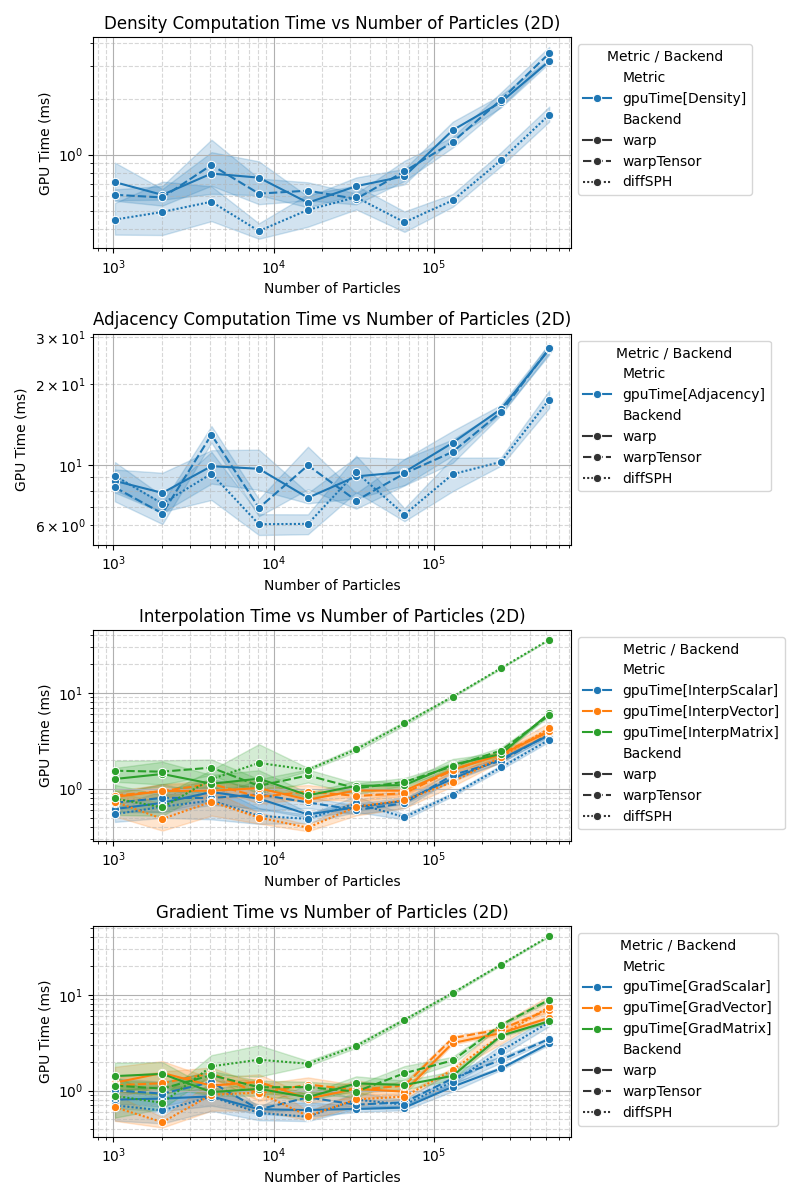

In [72]:

fig, axis = plt.subplots(4,1, figsize = (8,12), squeeze = False)

axf = axis.flatten()

curData =  stackedData[stackedData['Metric'] == 'gpuTime[Density]']

sns.lineplot(data = curData, x = 'Particles', y = 'Values', hue = 'Metric', style = 'Backend', ax = axf[0], marker = 'o')
axf[0].set_xlabel('Number of Particles')
axf[0].set_ylabel('GPU Time (ms)')
axf[0].set_title('Density Computation Time vs Number of Particles (2D)')

curData =  stackedData[stackedData['Metric'] == 'gpuTime[Adjacency]']
sns.lineplot(data = curData, x = 'Particles', y = 'Values', hue = 'Metric', style = 'Backend', ax = axf[1], marker = 'o')
axf[1].set_xlabel('Number of Particles')
axf[1].set_ylabel('GPU Time (ms)')
axf[1].set_title('Adjacency Computation Time vs Number of Particles (2D)')

curData = stackedData[np.logical_or(np.logical_or(stackedData['Metric'] == 'gpuTime[InterpScalar]', stackedData['Metric'] == 'gpuTime[InterpVector]'), stackedData['Metric'] == 'gpuTime[InterpMatrix]')]
sns.lineplot(data = curData, x = 'Particles', y = 'Values', hue = 'Metric', style = 'Backend', ax = axf[2], marker = 'o')
axf[2].set_xlabel('Number of Particles')
axf[2].set_ylabel('GPU Time (ms)')
# axf[2].set_ylabel(None)
axf[2].set_title('Interpolation Time vs Number of Particles (2D)')

curData = stackedData[np.logical_or(np.logical_or(stackedData['Metric'] == 'gpuTime[GradScalar]', stackedData['Metric'] == 'gpuTime[GradVector]'), stackedData['Metric'] == 'gpuTime[GradMatrix]')]
sns.lineplot(data = curData, x = 'Particles', y = 'Values', hue = 'Metric', style = 'Backend', ax = axf[3], marker = 'o')
axf[3].set_xlabel('Number of Particles')
axf[3].set_ylabel('GPU Time (ms)')
# axf[3].set_ylabel(None)
axf[3].set_title('Gradient Time vs Number of Particles (2D)')

for ax in axis.flatten():
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.grid(True, which = 'major')
    ax.grid(True, which = 'minor', linestyle = '--', alpha = 0.5)
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles=handles, labels=labels, title='Metric / Backend', loc='upper left', bbox_to_anchor=(1, 1))
    
fig.tight_layout()

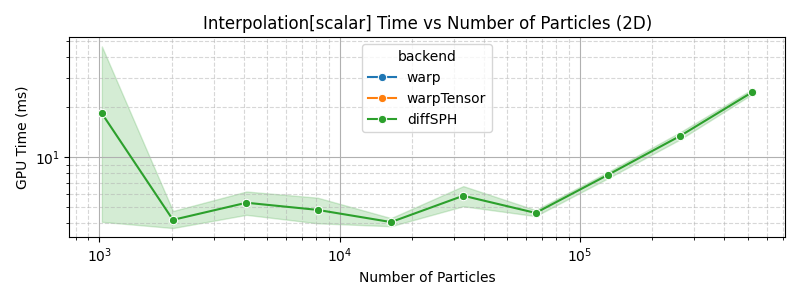

In [55]:
fig, axis = plt.subplots(1,1, figsize = (8,3), squeeze = False)

sns.lineplot(data = pdData[pdData['dim'] == 2], x = 'numParticles', y = 'gpuTime[Kernel]', hue = 'backend', ax = axis[0,0], marker = 'o')
axis[0,0].set_xscale('log')
axis[0,0].set_yscale('log')
axis[0,0].set_xlabel('Number of Particles')
axis[0,0].set_ylabel('GPU Time (ms)')
axis[0,0].set_title('Interpolation[scalar] Time vs Number of Particles (2D)')
axis[0,0].grid(True, which = 'major')
axis[0,0].grid(True, which = 'minor', linestyle = '--', alpha = 0.5)

fig.tight_layout()

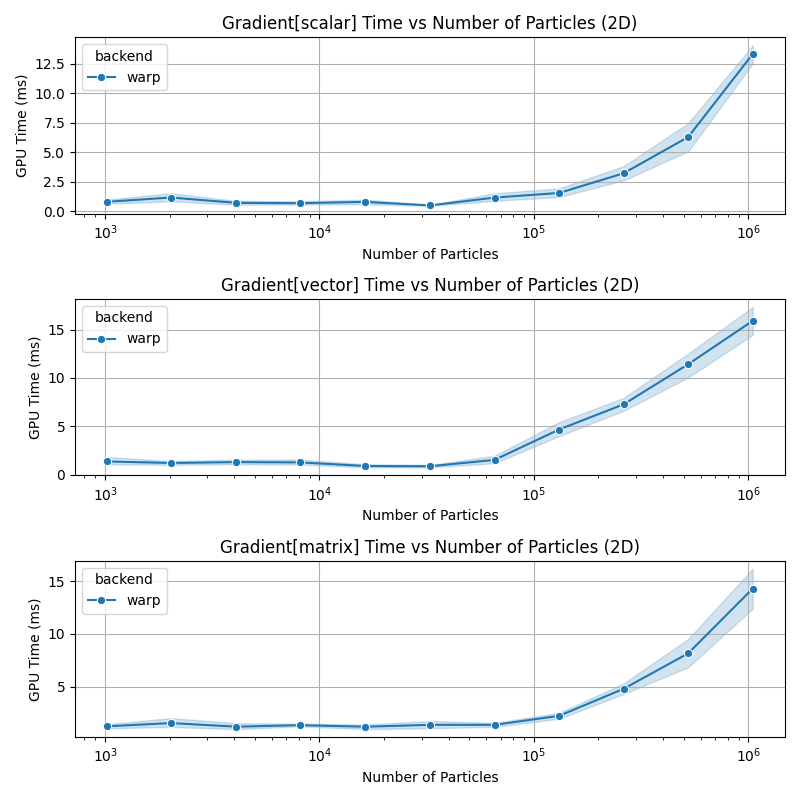

In [41]:
fig, axis = plt.subplots(3,1, figsize = (8,8), squeeze = False)

sns.lineplot(data = pdData[pdData['dim'] == 2], x = 'numParticles', y = 'gpuTime[GradScalar]', hue = 'backend', ax = axis[0,0], marker = 'o')
axis[0,0].set_xscale('log')
axis[0,0].set_xlabel('Number of Particles')
axis[0,0].set_ylabel('GPU Time (ms)')
axis[0,0].set_title('Gradient[scalar] Time vs Number of Particles (2D)')
axis[0,0].grid(True)

sns.lineplot(data = pdData[pdData['dim'] == 2], x = 'numParticles', y = 'gpuTime[GradVector]', hue = 'backend', ax = axis[1,0], marker = 'o')
axis[1,0].set_xscale('log')
axis[1,0].set_xlabel('Number of Particles')
axis[1,0].set_ylabel('GPU Time (ms)')
axis[1,0].set_title('Gradient[vector] Time vs Number of Particles (2D)')
axis[1,0].grid(True)

sns.lineplot(data = pdData[pdData['dim'] == 2], x = 'numParticles', y = 'gpuTime[GradMatrix]', hue = 'backend', ax = axis[2,0], marker = 'o')
axis[2,0].set_xscale('log')
axis[2,0].set_xlabel('Number of Particles')
axis[2,0].set_ylabel('GPU Time (ms)')
axis[2,0].set_title('Gradient[matrix] Time vs Number of Particles (2D)')
axis[2,0].grid(True)

fig.tight_layout()